# VGG 16 with Transfer Learning

### Importing Libraries

In [128]:
import numpy as np
from glob import glob
import matplotlib.pyplot as plt
import os

import warnings
warnings.filterwarnings("ignore", category=FutureWarning)

In [129]:
import tensorflow as tf
from keras.layers import Input, Lambda, Dense, Flatten
from keras.models import Model
from tensorflow.keras import models, layers
from keras.applications.vgg16 import VGG16
from keras.applications.vgg16 import preprocess_input
import tensorflow_datasets as tfds
from tensorflow.keras.utils import to_categorical
from keras.preprocessing import image
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from keras.models import Sequential

import warnings
warnings.filterwarnings("ignore", category=FutureWarning)

### Load Dataset

In [162]:
dataset=tf.keras.preprocessing.image_dataset_from_directory(
        'dataset-original')

Found 2527 files belonging to 6 classes.


In [163]:
dataset_name = dataset
class_names = dataset_name.class_names
print(class_names)

['cardboard', 'glass', 'metal', 'paper', 'plastic', 'trash']


In [164]:
BATCH_SIZE = 32
IMAGE_SIZE = [244,244]
SEED = 123
VALIDATION_SPLIT = 0.2
TEST_SPLIT = 0.1

In [165]:
# Load the entire dataset
full_ds = tf.keras.preprocessing.image_dataset_from_directory(
    'dataset-original',
    image_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE,
    seed=SEED
)

Found 2527 files belonging to 6 classes.


In [166]:
# Calculate splits based on NUMBER OF BATCHES (not images)
total_batches = len(full_ds)
num_test_batches = int(total_batches * TEST_SPLIT)
num_val_batches = int(total_batches * VALIDATION_SPLIT)
num_train_batches = total_batches - num_test_batches - num_val_batches

print(f'Total Batches: {total_batches}')
print(f'Batches allocated for Training: {num_train_batches}')
print(f'Batches allocated for Validation: {num_val_batches}')
print(f'Batches allocated for Testing: {num_test_batches}')

# Approximate total images (last batch might be smaller)
approx_total_images = total_batches * BATCH_SIZE
print(f'Approximate Total Images: {approx_total_images}')

# Create datasets using batch-based slicing
train_ds = full_ds.take(num_train_batches)
val_ds = full_ds.skip(num_train_batches).take(num_val_batches)
test_ds = full_ds.skip(num_train_batches + num_val_batches)

def count_images_in_dataset(dataset):
    count = 0
    for batch in dataset:
        count += batch[0].shape[0]  # batch[0] is images, shape[0] is batch size
    return count

print(f'Actual images in train_ds: {count_images_in_dataset(train_ds)}')
print(f'Actual images in val_ds: {count_images_in_dataset(val_ds)}')
print(f'Actual images in test_ds: {count_images_in_dataset(test_ds)}')

Total Batches: 79
Batches allocated for Training: 57
Batches allocated for Validation: 15
Batches allocated for Testing: 7
Approximate Total Images: 2528
Actual images in train_ds: 1824
Actual images in val_ds: 480
Actual images in test_ds: 223


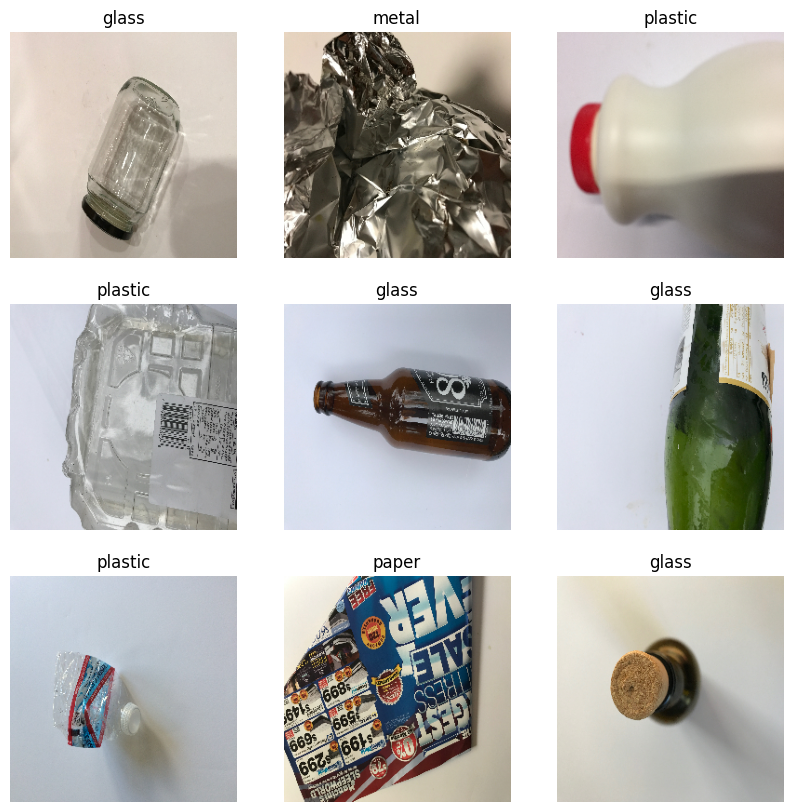

In [167]:
# Display first 9 images

plt.figure(figsize=(10, 10))
for x, y in train_ds.take(1):
  for i in range(9):
    ax = plt.subplot(3, 3, i + 1)
    plt.imshow(x[i].numpy().astype("uint8"))
    plt.title(class_names[y[i]])
    plt.axis("off")

### Data Augmentation

In [170]:
# Create data generator for data augmentation in training set
train_datagen = ImageDataGenerator(
    rescale=1./255,
    shear_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True,
    validation_split=0.2
)

In [171]:
# Create training and validation data generators
train_generator = train_datagen.flow_from_directory(
    'dataset-original',
    target_size=(244, 244),  # Resize images to this size
    batch_size=32,
    class_mode='categorical',  # Use 'categorical' for multi-class classification
    subset='training',  # Set as training data
    seed=123  # for reproducibility
)

val_generator = train_datagen.flow_from_directory(
    'dataset-original',
    target_size=(244, 244),
    batch_size=32,
    class_mode='categorical',
    subset='validation',  # Set as validation data
    seed=123
)

Found 2024 images belonging to 6 classes.
Found 503 images belonging to 6 classes.


In [172]:
class_names = train_generator.class_indices  # Returns a dictionary of class names and indices
num_classes = len(train_generator.class_indices)  # Number of classes

### Feature Extraction

### Model

In [173]:
vgg = VGG16(input_shape=IMAGE_SIZE + [3], weights='imagenet', include_top=False)

In [174]:
for layer in vgg.layers:
  layer.trainable = False # freeze

In [175]:
x = Flatten()(vgg.output)
prediction = tf.keras.layers.Dense(num_classes, activation='softmax')(x)
model = tf.keras.Model(inputs=vgg.input, outputs=prediction)

In [176]:
model.summary()

Model: "functional_19"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━┓
┃ Layer (type)                       ┃ Output Shape                  ┃     Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━┩
│ input_layer_21 (InputLayer)        │ (None, 244, 244, 3)           │           0 │
├────────────────────────────────────┼───────────────────────────────┼─────────────┤
│ block1_conv1 (Conv2D)              │ (None, 244, 244, 64)          │       1,792 │
├────────────────────────────────────┼───────────────────────────────┼─────────────┤
│ block1_conv2 (Conv2D)              │ (None, 244, 244, 64)          │      36,928 │
├────────────────────────────────────┼───────────────────────────────┼─────────────┤
│ block1_pool (MaxPooling2D)         │ (None, 122, 122, 64)          │           0 │
├────────────────────────────────────┼───────────────────────────────┼─────────────┤
│ block2_conv1 (Conv2D)              │ (None, 122, 122, 128)         │      73,856 │
├────────────────────────────────────┼───────────────────────────────┼─────────────┤
│ block2_conv2 (Conv2D)              │ (None, 122, 122, 128)         │     147,584 │
├────────────────────────────────────┼───────────────────────────────┼─────────────┤
│ block2_pool (MaxPooling2D)         │ (None, 61, 61, 128)           │           0 │
├────────────────────────────────────┼───────────────────────────────┼─────────────┤
│ block3_conv1 (Conv2D)              │ (None, 61, 61, 256)           │     295,168 │
├────────────────────────────────────┼───────────────────────────────┼─────────────┤
│ block3_conv2 (Conv2D)              │ (None, 61, 61, 256)           │     590,080 │
├────────────────────────────────────┼───────────────────────────────┼─────────────┤
│ block3_conv3 (Conv2D)              │ (None, 61, 61, 256)           │     590,080 │
├────────────────────────────────────┼───────────────────────────────┼─────────────┤
│ block3_pool (MaxPooling2D)         │ (None, 30, 30, 256)           │           0 │
├────────────────────────────────────┼───────────────────────────────┼─────────────┤
│ block4_conv1 (Conv2D)              │ (None, 30, 30, 512)           │   1,180,160 │
├────────────────────────────────────┼───────────────────────────────┼─────────────┤
│ block4_conv2 (Conv2D)              │ (None, 30, 30, 512)           │   2,359,808 │
├────────────────────────────────────┼───────────────────────────────┼─────────────┤
│ block4_conv3 (Conv2D)              │ (None, 30, 30, 512)           │   2,359,808 │
├────────────────────────────────────┼───────────────────────────────┼─────────────┤
│ block4_pool (MaxPooling2D)         │ (None, 15, 15, 512)           │           0 │
├────────────────────────────────────┼───────────────────────────────┼─────────────┤
│ block5_conv1 (Conv2D)              │ (None, 15, 15, 512)           │   2,359,808 │
├────────────────────────────────────┼───────────────────────────────┼─────────────┤
│ block5_conv2 (Conv2D)              │ (None, 15, 15, 512)           │   2,359,808 │
├────────────────────────────────────┼───────────────────────────────┼─────────────┤
│ block5_conv3 (Conv2D)              │ (None, 15, 15, 512)           │   2,359,808 │
├────────────────────────────────────┼───────────────────────────────┼─────────────┤
│ block5_pool (MaxPooling2D)         │ (None, 7, 7, 512)             │           0 │
├────────────────────────────────────┼───────────────────────────────┼─────────────┤
│ flatten_13 (Flatten)               │ (None, 25088)                 │           0 │
├────────────────────────────────────┼───────────────────────────────┼─────────────┤
│ dense_17 (Dense)                   │ (None, 6)                     │     150,534 │
└────────────────────────────────────┴───────────────────────────────┴─────────────┘

 Total params: 14,865,222 (56.71 MB)

 Trainable params: 150,534 (588.02 KB)

 Non-trainable params: 14,714,688 (56.13 MB)

In [177]:
# Compile the model
model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

history = model.fit(train_ds, validation_data=val_ds, epochs=10)

Epoch 1/10
57/57 ━━━━━━━━━━━━━━━━━━━━ 159s 3s/step - accuracy: 0.5205 - loss: 12.6635 - val_accuracy: 0.7958 - val_loss: 4.5360
Epoch 2/10
57/57 ━━━━━━━━━━━━━━━━━━━━ 152s 3s/step - accuracy: 0.9128 - loss: 1.4308 - val_accuracy: 0.8333 - val_loss: 4.8503
Epoch 3/10
57/57 ━━━━━━━━━━━━━━━━━━━━ 148s 3s/step - accuracy: 0.9529 - loss: 0.7610 - val_accuracy: 0.8521 - val_loss: 4.0144
Epoch 4/10
57/57 ━━━━━━━━━━━━━━━━━━━━ 157s 3s/step - accuracy: 0.9621 - loss: 0.3642 - val_accuracy: 0.8542 - val_loss: 4.6510
Epoch 5/10
57/57 ━━━━━━━━━━━━━━━━━━━━ 151s 3s/step - accuracy: 0.9851 - loss: 0.1720 - val_accuracy: 0.8708 - val_loss: 3.6802
Epoch 6/10
57/57 ━━━━━━━━━━━━━━━━━━━━ 217s 4s/step - accuracy: 0.9839 - loss: 0.2231 - val_accuracy: 0.8708 - val_loss: 3.7399
Epoch 7/10
57/57 ━━━━━━━━━━━━━━━━━━━━ 213s 4s/step - accuracy: 0.9866 - loss: 0.1518 - val_accuracy: 0.8479 - val_loss: 5.7623
Epoch 8/10
57/57 ━━━━━━━━━━━━━━━━━━━━ 214s 4s/step - accuracy: 0.9914 - loss: 0.1960 - val_accuracy: 0.8604 - 

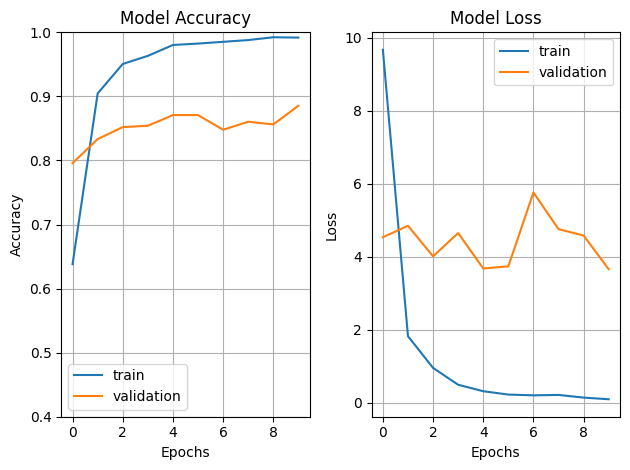

In [178]:
fig1 = plt.gcf()
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.axis(ymin=0.4,ymax=1)
plt.grid()
plt.title('Model Accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epochs')
plt.legend(['train', 'validation'])

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.grid()
plt.title('Model Loss')
plt.ylabel('Loss')
plt.xlabel('Epochs')
plt.legend(['train', 'validation'])

plt.tight_layout()
plt.show()

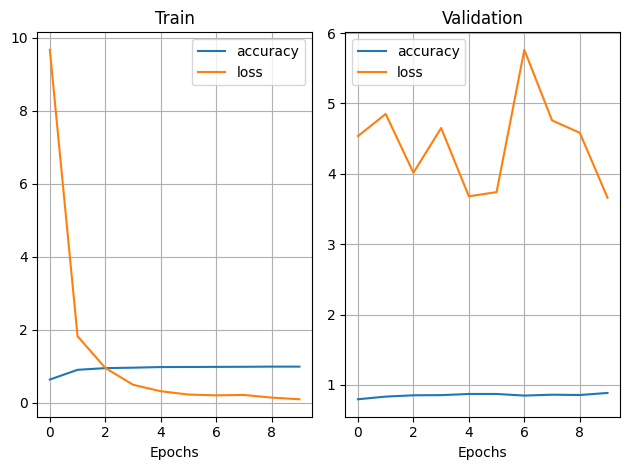

In [179]:
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'])
plt.plot(history.history['loss'])
plt.grid()
plt.title('Train')
plt.xlabel('Epochs')
plt.legend(['accuracy', 'loss'])

plt.subplot(1, 2, 2)
plt.plot(history.history['val_accuracy'])
plt.plot(history.history['val_loss'])
plt.grid()
plt.title('Validation')
plt.xlabel('Epochs')
plt.legend(['accuracy', 'loss'])

plt.tight_layout()
plt.show()

### Making predictions using validation dataset

In [188]:
print(f'Test images (batches): {test_ds.cardinality().numpy()}')

Test images (batches): 7


In [189]:
# Make predictions on the test dataset (test_ds)
y_pred_probs = model.predict(test_ds)

# For multi-class classification, convert probabilities to class predictions
y_pred = np.argmax(y_pred_probs, axis=1)  # Get the predicted classes

7/7 ━━━━━━━━━━━━━━━━━━━━ 32s 3s/step  


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 161ms/step


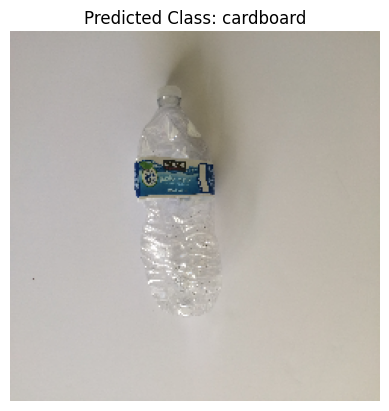

In [197]:
# Constants
IMAGE_PATH = 'dataset-original/plastic/plastic5.jpg'  # Path to the single image
IMAGE_SIZE = (244, 244)  

# Load the image
img = image.load_img(IMAGE_PATH, target_size=IMAGE_SIZE)
img_array = image.img_to_array(img)  # Convert image to array

# Preprocess the image
img_array = np.expand_dims(img_array, axis=0)  # Add batch dimension
img_array /= 255.0  # Normalize to [0, 1] if trained with this normalization

# Make predictions
predictions = model.predict(img_array)
predicted_class = np.argmax(predictions, axis=1)

# Display the image and the predicted class
class_names = ['cardboard', 'glass', 'metal', 'paper', 'plastic', 'trash'] 
predicted_class_name = class_names[predicted_class[0]]

# Show the image with prediction
plt.imshow(img)
plt.title(f'Predicted Class: {predicted_class_name}')
plt.axis('off')  # Hide axis
plt.show()

### Measurement matrix

In [191]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

In [192]:
# Extract true labels from the validation dataset
y_true = []

# Iterate over the validation dataset to retrieve true labels
for images, labels in test_ds:
    # Since labels are not one-hot encoded, we can directly extend y_true with labels
    y_true.extend(labels.numpy())  # No need for np.argmax

# Convert y_true to a NumPy array and flatten if needed
y_true = np.array(y_true).flatten()  # Flatten if labels are in (batch_size, 1) shape

In [193]:
# Calculate metrics
accuracy = accuracy_score(y_true, y_pred)
precision = precision_score(y_true, y_pred, average='weighted')
recall = recall_score(y_true, y_pred, average='weighted')
f1 = f1_score(y_true, y_pred, average='weighted')
conf_matrix = confusion_matrix(y_true, y_pred)
error_rate = 1 - accuracy

# Print the metrics
print(f'Accuracy: {accuracy:.4f}')
print(f'Precision: {precision:.4f}')
print(f'Recall: {recall:.4f}')
print(f'F1 Score: {f1:.4f}')
print(f'Error Rate: {error_rate:.4f}')
print(f'Confusion Matrix:\n{conf_matrix}')

Accuracy: 0.1659
Precision: 0.1648
Recall: 0.1659
F1 Score: 0.1652
Error Rate: 0.8341
Confusion Matrix:
[[ 6  5  4 14  6  1]
 [ 8  8  6 11  9  2]
 [ 6  9  6  8  8  2]
 [ 8  9 12 10 10  3]
 [10  7  7  9  7  1]
 [ 2  4  0  3  2  0]]
